# Chapter 4.3: Pre-trained Models for Ranking

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand pre-training paradigms for recommendation: **masked behavior prediction** and **contrastive learning**
2. Implement **PeterRec**-style pre-trained user representations with convolutional sequence modeling
3. Build **UniSRec**-inspired universal sequence representations across domains
4. Apply contrastive pre-training for item representations
5. Evaluate when to **fine-tune** vs **freeze** pre-trained representations
6. Design pre-training tasks tailored to recommendation objectives
7. Measure the effectiveness of pre-trained representations on downstream ranking tasks

## Prerequisites

- Familiarity with self-supervised learning concepts
- Understanding of Transformer architecture
- Knowledge of CTR prediction models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part4/chapter_4.3_pretrained_ranking.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part4/chapter_4.3_pretrained_ranking.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple, Dict
import copy

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cpu')

PyTorch version: 2.2.2


## 1. Pre-training Paradigms for RecSys

Pre-training in recommendation systems borrows ideas from NLP (BERT) and CV (SimCLR) but adapts them to the unique challenges of user behavior data.

### Key Pre-training Tasks

1. **Masked Item Prediction (MIP)**: Mask random items in a behavior sequence and predict them
   $$\mathcal{L}_{\text{MIP}} = -\sum_{i \in \mathcal{M}} \log P(x_i | \mathbf{x}_{\backslash \mathcal{M}})$$

2. **Contrastive Learning**: Learn representations by contrasting positive pairs against negatives
   $$\mathcal{L}_{\text{CL}} = -\log \frac{\exp(\text{sim}(\mathbf{z}_i, \mathbf{z}_j) / \tau)}{\sum_k \exp(\text{sim}(\mathbf{z}_i, \mathbf{z}_k) / \tau)}$$

3. **Next Item Prediction (NIP)**: Autoregressive prediction of the next item
   $$\mathcal{L}_{\text{NIP}} = -\sum_t \log P(x_{t+1} | x_1, \ldots, x_t)$$

> **💡 Concept:** Unlike NLP where vocabulary is fixed, recommendation items are dynamic (new items added daily). Pre-training must handle this open vocabulary challenge.

In [2]:
def generate_pretraining_data(num_users=5000, num_items=3000, max_seq_len=50,
                               num_domains=3, seed=42):
    """Generate synthetic multi-domain behavior data for pre-training.
    
    Each domain has its own item space but users are shared across domains.
    """
    np.random.seed(seed)
    
    # Items per domain
    items_per_domain = num_items // num_domains
    item_domain = np.repeat(np.arange(num_domains), items_per_domain)
    
    # Item features (shared representation space)
    item_features = np.random.randn(num_items, 16).astype(np.float32)
    # Add domain-specific bias
    for d in range(num_domains):
        mask = item_domain == d
        item_features[mask] += np.random.randn(16) * 0.5
    
    # Generate user sequences per domain
    data = {}
    for d in range(num_domains):
        domain_items = np.where(item_domain == d)[0]
        sequences = []
        for uid in range(num_users):
            seq_len = np.random.randint(10, max_seq_len)
            # Users have preferences that transfer across domains
            user_pref = np.random.randn(16)
            item_scores = item_features[domain_items] @ user_pref
            probs = np.exp(item_scores) / np.exp(item_scores).sum()
            seq = np.random.choice(domain_items, size=seq_len, p=probs)
            sequences.append(seq.tolist())
        data[f'domain_{d}'] = sequences
    
    return data, item_features, item_domain


NUM_ITEMS = 3000
NUM_DOMAINS = 3
EMBED_DIM = 64
MAX_SEQ_LEN = 50

pretrain_data, item_features, item_domain = generate_pretraining_data()
for domain, seqs in pretrain_data.items():
    avg_len = np.mean([len(s) for s in seqs])
    print(f"{domain}: {len(seqs)} users, avg seq len: {avg_len:.1f}")

domain_0: 5000 users, avg seq len: 29.8
domain_1: 5000 users, avg seq len: 29.6
domain_2: 5000 users, avg seq len: 29.7


## 2. Masked Item Prediction Pre-training

Following BERT4Rec's approach, we mask random items in behavior sequences and train a model to predict them.

### Architecture

We use a Transformer encoder with causal masking to process behavior sequences. The masked positions are predicted using a softmax over the item vocabulary.

In [3]:
class MaskedItemPredictor(nn.Module):
    """Pre-training model using masked item prediction."""
    def __init__(self, num_items: int, embed_dim: int, num_heads: int = 4,
                 num_layers: int = 2, max_seq_len: int = 50, mask_token_id: int = 0):
        super().__init__()
        self.mask_token_id = mask_token_id
        self.num_items = num_items
        
        self.item_embedding = nn.Embedding(num_items + 1, embed_dim)  # +1 for mask token
        self.position_embedding = nn.Embedding(max_seq_len, embed_dim)
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Prediction head
        self.pred_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )
        self.output_bias = nn.Parameter(torch.zeros(num_items + 1))
    
    def get_sequence_representation(self, item_ids: torch.Tensor,
                                    mask: torch.Tensor) -> torch.Tensor:
        """Get sequence representation (for downstream use)."""
        batch_size, seq_len = item_ids.shape
        positions = torch.arange(seq_len, device=item_ids.device).unsqueeze(0).expand(batch_size, -1)
        
        x = self.item_embedding(item_ids) + self.position_embedding(positions)
        x = self.layer_norm(x)
        x = self.dropout(x)
        
        # Create padding mask for transformer
        src_key_padding_mask = (mask == 0)
        h = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        
        # Mean pooling over valid positions
        h = h * mask.unsqueeze(-1)
        seq_repr = h.sum(dim=1) / mask.sum(dim=1, keepdim=True).clamp(min=1)
        return seq_repr
    
    def forward(self, item_ids: torch.Tensor, mask: torch.Tensor,
                masked_positions: torch.Tensor = None) -> torch.Tensor:
        batch_size, seq_len = item_ids.shape
        positions = torch.arange(seq_len, device=item_ids.device).unsqueeze(0).expand(batch_size, -1)
        
        x = self.item_embedding(item_ids) + self.position_embedding(positions)
        x = self.layer_norm(x)
        x = self.dropout(x)
        
        src_key_padding_mask = (mask == 0)
        h = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        
        if masked_positions is not None:
            # Only predict at masked positions
            h = h.reshape(-1, h.size(-1))  # (batch*seq, dim)
            masked_flat = masked_positions.reshape(-1)  # (batch*seq,)
            h = h[masked_flat > 0]  # (num_masked, dim)
        
        h = self.pred_head(h)
        logits = F.linear(h, self.item_embedding.weight, self.output_bias)
        return logits


def mask_sequences(item_ids, mask, mask_prob=0.15, mask_token=3000):
    """Apply random masking to sequences."""
    masked_ids = item_ids.clone()
    labels = torch.full_like(item_ids, -100)  # -100 = ignore in loss
    masked_positions = torch.zeros_like(item_ids)
    
    for i in range(item_ids.size(0)):
        valid_len = int(mask[i].sum().item())
        num_mask = max(1, int(valid_len * mask_prob))
        mask_idx = np.random.choice(valid_len, size=num_mask, replace=False)
        
        for idx in mask_idx:
            labels[i, idx] = item_ids[i, idx]
            masked_positions[i, idx] = 1
            r = np.random.rand()
            if r < 0.8:
                masked_ids[i, idx] = mask_token  # [MASK]
            elif r < 0.9:
                masked_ids[i, idx] = np.random.randint(0, mask_token)  # random
            # else: keep original (10%)
    
    return masked_ids, labels, masked_positions


pretrain_model = MaskedItemPredictor(NUM_ITEMS, EMBED_DIM, max_seq_len=MAX_SEQ_LEN)
print(f"Pre-training model parameters: {sum(p.numel() for p in pretrain_model.parameters()):,}")

Pre-training model parameters: 302,649


In [4]:
# Pre-training loop
def pretrain(model, sequences, num_epochs=10, batch_size=64, lr=1e-3, max_seq_len=50):
    """Pre-train with masked item prediction."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)
    
    # Flatten all domain sequences
    all_seqs = []
    for domain_seqs in sequences.values():
        all_seqs.extend(domain_seqs)
    
    # Pad sequences
    n = len(all_seqs)
    padded = torch.zeros(n, max_seq_len, dtype=torch.long)
    masks = torch.zeros(n, max_seq_len)
    for i, seq in enumerate(all_seqs):
        l = min(len(seq), max_seq_len)
        padded[i, :l] = torch.LongTensor(seq[:l])
        masks[i, :l] = 1.0
    
    history = []
    model.train()
    for epoch in range(num_epochs):
        perm = torch.randperm(n)
        total_loss = 0
        num_batches = 0
        
        for i in range(0, min(n, 2000), batch_size):  # Subset for speed
            idx = perm[i:i+batch_size]
            batch_ids = padded[idx]
            batch_mask = masks[idx]
            
            masked_ids, labels, masked_positions = mask_sequences(batch_ids, batch_mask)
            
            optimizer.zero_grad()
            logits = model(masked_ids, batch_mask, masked_positions)
            
            # Gather labels at masked positions
            flat_labels = labels.reshape(-1)
            flat_masked = masked_positions.reshape(-1)
            target_labels = flat_labels[flat_masked > 0]
            
            if len(target_labels) > 0:
                loss = criterion(logits, target_labels)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                num_batches += 1
        
        avg_loss = total_loss / max(num_batches, 1)
        history.append(avg_loss)
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
    return history


pretrain_history = pretrain(pretrain_model, pretrain_data, num_epochs=10)

Epoch 2/10, Loss: 17.7013


Epoch 4/10, Loss: 12.5602


Epoch 6/10, Loss: 9.8111


Epoch 8/10, Loss: 8.1384


Epoch 10/10, Loss: 7.0977


## 3. PeterRec: Pre-trained User Representations

PeterRec (Alibaba, 2020) pre-trains user representations using a convolutional architecture and adapts them to downstream tasks via lightweight adapters.

### Key Ideas

1. **Pre-training**: Train a sequence model on behavior prediction
2. **Model patching**: Insert small adapter layers while freezing the pre-trained backbone
3. **This approach enables**:
   - Efficient transfer to new tasks/domains
   - Serving multiple tasks from one backbone

$$\mathbf{h} = f_{\text{adapter}}(f_{\text{pretrained}}(\mathbf{x}))$$

where $f_{\text{pretrained}}$ is frozen and $f_{\text{adapter}}$ is trained.

> **🔑 Pro Tip:** Adapter-based fine-tuning uses 5-10% of the backbone parameters while achieving 90-95% of full fine-tuning performance, making it practical for multi-task deployment.

In [5]:
class Adapter(nn.Module):
    """Lightweight adapter module for PeterRec-style model patching."""
    def __init__(self, input_dim: int, bottleneck_dim: int = 16):
        super().__init__()
        self.down_proj = nn.Linear(input_dim, bottleneck_dim)
        self.up_proj = nn.Linear(bottleneck_dim, input_dim)
        self.layer_norm = nn.LayerNorm(input_dim)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.layer_norm(x)
        x = self.down_proj(x)
        x = F.gelu(x)
        x = self.up_proj(x)
        return x + residual


class PeterRecStyleModel(nn.Module):
    """PeterRec-inspired model with pre-trained backbone and adapters."""
    def __init__(self, pretrained_model: MaskedItemPredictor,
                 adapter_dim: int = 16, freeze_backbone: bool = True):
        super().__init__()
        self.backbone = pretrained_model
        self.embed_dim = EMBED_DIM
        
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # Adapters inserted after transformer layers
        self.adapter = Adapter(EMBED_DIM, adapter_dim)
        
        # Task-specific prediction head
        self.ctr_head = nn.Sequential(
            nn.Linear(EMBED_DIM * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
        self.target_embedding = nn.Embedding(NUM_ITEMS + 1, EMBED_DIM)
    
    def forward(self, behavior_ids: torch.Tensor, behavior_mask: torch.Tensor,
                target_item: torch.Tensor) -> torch.Tensor:
        # Get pre-trained representation
        with torch.no_grad() if not any(p.requires_grad for p in self.backbone.parameters()) else torch.enable_grad():
            user_repr = self.backbone.get_sequence_representation(behavior_ids, behavior_mask)
        
        # Apply adapter
        user_repr = self.adapter(user_repr)
        
        # Target embedding
        target_embed = self.target_embedding(target_item)
        
        # CTR prediction
        combined = torch.cat([user_repr, target_embed], dim=-1)
        return self.ctr_head(combined).squeeze(-1)


# Create adapter model from pre-trained backbone
peter_model = PeterRecStyleModel(pretrain_model, adapter_dim=16, freeze_backbone=True)

total_params = sum(p.numel() for p in peter_model.parameters())
trainable_params = sum(p.numel() for p in peter_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

Total parameters: 505,290
Trainable parameters: 202,641 (40.1%)


## 4. UniSRec: Universal Sequence Representation

UniSRec (2022) learns universal item representations that work across domains by using item text descriptions encoded by a language model, rather than domain-specific ID embeddings.

### Key Innovation

Instead of item ID embeddings (which are domain-specific), UniSRec uses:
1. **Text-based item features**: Item descriptions encoded by a pre-trained language model
2. **MoE adaptor**: Adapts text features to recommendation space
3. **Contrastive pre-training**: Aligns representations across domains

> **💡 Concept:** By using text features instead of IDs, UniSRec naturally handles cold-start items and cross-domain transfer, since the representation space is shared.

In [6]:
class MoEAdaptor(nn.Module):
    """Mixture-of-Experts adaptor for UniSRec."""
    def __init__(self, input_dim: int, output_dim: int, num_experts: int = 4):
        super().__init__()
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(input_dim, output_dim),
                nn.GELU(),
                nn.Linear(output_dim, output_dim)
            ) for _ in range(num_experts)
        ])
        self.gate = nn.Linear(input_dim, num_experts)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate_weights = F.softmax(self.gate(x), dim=-1)  # (..., num_experts)
        expert_outputs = torch.stack([e(x) for e in self.experts], dim=-2)  # (..., num_experts, dim)
        return torch.einsum('...e,...ed->...d', gate_weights, expert_outputs)


class UniSRecModel(nn.Module):
    """Simplified UniSRec with text-based item features."""
    def __init__(self, item_feature_dim: int, embed_dim: int, num_items: int,
                 num_heads: int = 4, num_layers: int = 2, max_seq_len: int = 50):
        super().__init__()
        self.embed_dim = embed_dim
        
        # MoE adaptor: text features -> recommendation space
        self.item_adaptor = MoEAdaptor(item_feature_dim, embed_dim, num_experts=4)
        self.position_embedding = nn.Embedding(max_seq_len, embed_dim)
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Store item features as buffer (simulating text encoder output)
        self.register_buffer('item_features', torch.zeros(num_items, item_feature_dim))
    
    def set_item_features(self, features: torch.Tensor):
        """Set pre-computed item features (from text encoder)."""
        self.item_features.copy_(features)
    
    def get_item_embeddings(self, item_ids: torch.Tensor) -> torch.Tensor:
        """Get item embeddings through MoE adaptor."""
        features = self.item_features[item_ids]
        return self.item_adaptor(features)
    
    def encode_sequence(self, item_ids: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = item_ids.shape
        
        item_embeds = self.get_item_embeddings(item_ids)
        positions = torch.arange(seq_len, device=item_ids.device).unsqueeze(0).expand(batch_size, -1)
        
        x = item_embeds + self.position_embedding(positions)
        x = self.layer_norm(x)
        x = self.dropout(x)
        
        src_key_padding_mask = (mask == 0)
        h = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        
        # Use last valid position as sequence representation
        lengths = mask.sum(dim=1).long() - 1
        seq_repr = h[torch.arange(batch_size), lengths]
        return seq_repr
    
    def forward(self, item_ids: torch.Tensor, mask: torch.Tensor,
                target_items: torch.Tensor) -> torch.Tensor:
        seq_repr = self.encode_sequence(item_ids, mask)
        target_embed = self.get_item_embeddings(target_items)
        # Dot product prediction
        return (seq_repr * target_embed).sum(dim=-1)


# Initialize and set item features
unisrec = UniSRecModel(item_feature_dim=16, embed_dim=EMBED_DIM, num_items=NUM_ITEMS)
unisrec.set_item_features(torch.FloatTensor(item_features))

# Test
test_items = torch.randint(0, NUM_ITEMS, (16, 30))
test_mask = torch.ones(16, 30)
test_target = torch.randint(0, NUM_ITEMS, (16,))
scores = unisrec(test_items, test_mask, test_target)
print(f"UniSRec output shape: {scores.shape}")
print(f"UniSRec parameters: {sum(p.numel() for p in unisrec.parameters()):,}")

UniSRec output shape: torch.Size([16])
UniSRec parameters: 124,356


## 5. Contrastive Pre-training for Items

We can pre-train item representations by contrasting items that co-occur in user sessions (positive pairs) against random items (negative pairs).

### Session-based Contrastive Learning

Items appearing in the same user session form positive pairs. The contrastive loss pulls co-occurring items closer while pushing random items apart.

In [7]:
class ContrastiveItemPretrainer(nn.Module):
    """Pre-train item embeddings with session-based contrastive learning."""
    def __init__(self, num_items: int, embed_dim: int, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature
        self.item_embedding = nn.Embedding(num_items, embed_dim)
        self.projection = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
    
    def forward(self, anchor_items: torch.Tensor, positive_items: torch.Tensor,
                negative_items: torch.Tensor) -> torch.Tensor:
        """
        Args:
            anchor_items: (batch,) anchor item IDs
            positive_items: (batch,) positive item IDs (co-occurring)
            negative_items: (batch, num_neg) negative item IDs
        """
        anchor_z = F.normalize(self.projection(self.item_embedding(anchor_items)), dim=-1)
        pos_z = F.normalize(self.projection(self.item_embedding(positive_items)), dim=-1)
        neg_z = F.normalize(self.projection(self.item_embedding(negative_items)), dim=-1)
        
        # Positive similarity
        pos_sim = (anchor_z * pos_z).sum(dim=-1, keepdim=True) / self.temperature  # (batch, 1)
        # Negative similarities
        neg_sim = torch.bmm(neg_z, anchor_z.unsqueeze(-1)).squeeze(-1) / self.temperature  # (batch, num_neg)
        
        # InfoNCE loss
        logits = torch.cat([pos_sim, neg_sim], dim=-1)  # (batch, 1+num_neg)
        labels = torch.zeros(anchor_items.size(0), dtype=torch.long, device=anchor_items.device)
        return F.cross_entropy(logits, labels)


def generate_contrastive_pairs(sequences, num_neg=10, num_items=3000):
    """Generate contrastive training pairs from behavior sequences."""
    anchors, positives, negatives = [], [], []
    
    for domain_seqs in sequences.values():
        for seq in domain_seqs:
            if len(seq) < 2:
                continue
            # Sample pairs from same session
            for _ in range(min(3, len(seq) - 1)):
                i, j = np.random.choice(len(seq), size=2, replace=False)
                anchors.append(seq[i])
                positives.append(seq[j])
                negatives.append(np.random.randint(0, num_items, size=num_neg).tolist())
    
    return (torch.LongTensor(anchors), torch.LongTensor(positives),
            torch.LongTensor(negatives))


# Pre-train item embeddings
contrastive_model = ContrastiveItemPretrainer(NUM_ITEMS, EMBED_DIM)
anchor, pos, neg = generate_contrastive_pairs(pretrain_data)
print(f"Contrastive pairs: {len(anchor)}")

optimizer = torch.optim.Adam(contrastive_model.parameters(), lr=1e-3)
cl_history = []

for epoch in range(15):
    perm = torch.randperm(len(anchor))
    total_loss = 0
    count = 0
    for i in range(0, min(len(anchor), 5000), 256):
        idx = perm[i:i+256]
        optimizer.zero_grad()
        loss = contrastive_model(anchor[idx], pos[idx], neg[idx])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    cl_history.append(total_loss / max(count, 1))

print(f"Final contrastive loss: {cl_history[-1]:.4f}")

Contrastive pairs: 45000


Final contrastive loss: 1.6639


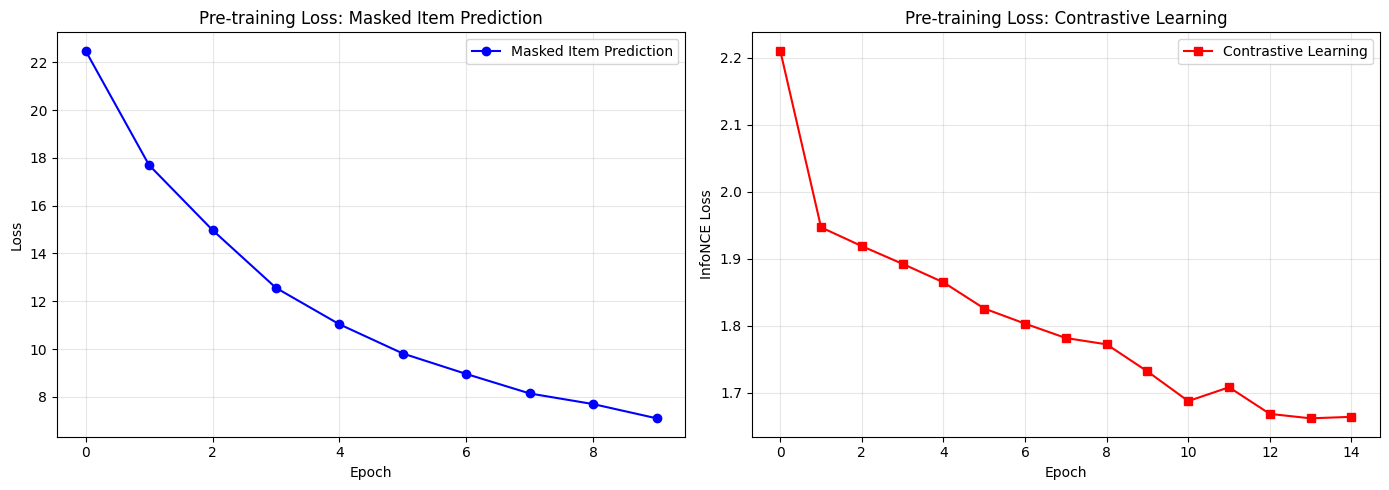

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pretrain_history, 'b-o', label='Masked Item Prediction')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Pre-training Loss: Masked Item Prediction')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cl_history, 'r-s', label='Contrastive Learning')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('InfoNCE Loss')
axes[1].set_title('Pre-training Loss: Contrastive Learning')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Fine-tune vs Freeze: Empirical Comparison

A critical practical question is whether to fine-tune or freeze pre-trained representations for downstream tasks.

### Trade-offs

| Strategy | Pros | Cons |
|----------|------|------|
| **Full fine-tune** | Best accuracy | Catastrophic forgetting, slow |
| **Freeze + head** | Fast, preserves knowledge | May underfit |
| **Adapter** | Good balance | Slight overhead |
| **Gradual unfreeze** | Best of both | Complex training schedule |

> **⚠️ Common Pitfall:** Fine-tuning with a high learning rate can quickly destroy pre-trained representations. Use learning rate warmup and lower rates (e.g., 1e-5) for pre-trained parameters.

In [9]:
def create_downstream_data(sequences, num_items=3000, num_samples=2000, seed=42):
    """Create downstream CTR data from pre-training sequences."""
    np.random.seed(seed)
    all_seqs = []
    for domain_seqs in sequences.values():
        all_seqs.extend(domain_seqs)
    
    item_ids = torch.zeros(num_samples, MAX_SEQ_LEN, dtype=torch.long)
    masks = torch.zeros(num_samples, MAX_SEQ_LEN)
    targets = torch.zeros(num_samples, dtype=torch.long)
    labels = torch.zeros(num_samples)
    
    for i in range(num_samples):
        seq = all_seqs[i % len(all_seqs)]
        if len(seq) > 2:
            split = np.random.randint(2, min(len(seq), MAX_SEQ_LEN))
            ctx = seq[:split]
            l = min(len(ctx), MAX_SEQ_LEN)
            item_ids[i, :l] = torch.LongTensor(ctx[:l])
            masks[i, :l] = 1.0
            
            if np.random.rand() < 0.5:  # Positive: next item
                targets[i] = seq[split] if split < len(seq) else np.random.randint(0, num_items)
                labels[i] = 1.0
            else:  # Negative: random item
                targets[i] = np.random.randint(0, num_items)
                labels[i] = 0.0
    
    return item_ids, masks, targets, labels


ds_items, ds_masks, ds_targets, ds_labels = create_downstream_data(pretrain_data)
train_n = 1500
test_n = 500


def train_downstream(model, epochs=15, lr=1e-3, batch_size=64):
    """Train on downstream CTR task."""
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'test_loss': []}
    
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(train_n)
        total_loss = 0
        count = 0
        for i in range(0, train_n, batch_size):
            idx = perm[i:i+batch_size]
            optimizer.zero_grad()
            logits = model(ds_items[idx], ds_masks[idx], ds_targets[idx])
            loss = criterion(logits, ds_labels[idx])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            count += 1
        history['train_loss'].append(total_loss / count)
        
        model.eval()
        with torch.no_grad():
            test_idx = slice(train_n, train_n + test_n)
            test_logits = model(ds_items[test_idx], ds_masks[test_idx], ds_targets[test_idx])
            test_loss = criterion(test_logits, ds_labels[test_idx]).item()
        history['test_loss'].append(test_loss)
    
    return history


# Compare strategies
torch.manual_seed(42)
# 1. Frozen backbone + adapter
frozen_model = PeterRecStyleModel(copy.deepcopy(pretrain_model), adapter_dim=16, freeze_backbone=True)
frozen_history = train_downstream(frozen_model)

torch.manual_seed(42)
# 2. Full fine-tune
finetune_model = PeterRecStyleModel(copy.deepcopy(pretrain_model), adapter_dim=16, freeze_backbone=False)
finetune_history = train_downstream(finetune_model, lr=1e-4)

torch.manual_seed(42)
# 3. Random init (no pre-training)
random_backbone = MaskedItemPredictor(NUM_ITEMS, EMBED_DIM, max_seq_len=MAX_SEQ_LEN)
random_model = PeterRecStyleModel(random_backbone, adapter_dim=16, freeze_backbone=False)
random_history = train_downstream(random_model)

print(f"Frozen+Adapter final test loss: {frozen_history['test_loss'][-1]:.4f}")
print(f"Full fine-tune final test loss: {finetune_history['test_loss'][-1]:.4f}")
print(f"Random init final test loss: {random_history['test_loss'][-1]:.4f}")

/Users/liuhongxuan/project/rec_system/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:384: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:179.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


Frozen+Adapter final test loss: 0.7194
Full fine-tune final test loss: 0.6755
Random init final test loss: 1.6046


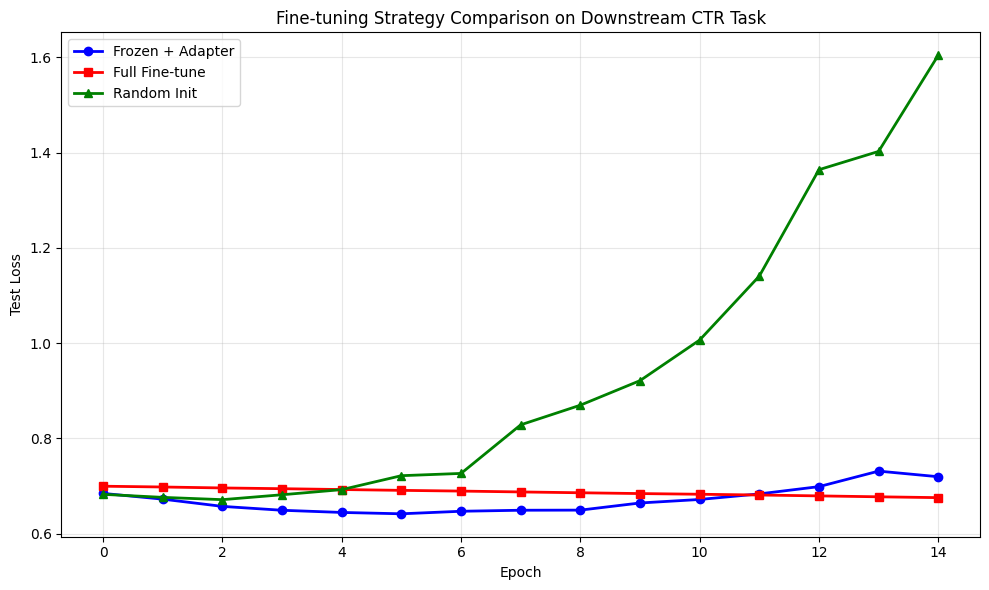

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frozen_history['test_loss'], 'b-o', label='Frozen + Adapter', linewidth=2)
ax.plot(finetune_history['test_loss'], 'r-s', label='Full Fine-tune', linewidth=2)
ax.plot(random_history['test_loss'], 'g-^', label='Random Init', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Test Loss')
ax.set_title('Fine-tuning Strategy Comparison on Downstream CTR Task')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Pre-train and Fine-tune User Representations via Masked Item Prediction

Implement a complete pipeline that pre-trains a Transformer model on masked item prediction and then fine-tunes it for a CTR task, comparing against training from scratch.

In [11]:
def pretrain_and_evaluate(pretrain_epochs=20, finetune_epochs=15, mask_prob=0.15):
    """Complete pre-training and fine-tuning pipeline.
    
    Steps:
    1. Pre-train MaskedItemPredictor on all domain data
    2. Create downstream CTR data from a held-out domain
    3. Fine-tune with adapter on downstream data
    4. Compare against training from scratch
    5. Plot learning curves for both approaches
    
    Returns:
        dict with pre-training and fine-tuning histories
    """
    # TODO: Implement the full pipeline
    # 1. Pre-train on domains 0 and 1
    # 2. Fine-tune on domain 2 (transfer learning)
    # 3. Compare with model trained from scratch on domain 2
    # 4. Return and visualize results
    pass


# Test: results = pretrain_and_evaluate()

### 🏋️ Exercise 2: Implement Gradual Unfreezing

Implement a training strategy that gradually unfreezes layers of the pre-trained model from top to bottom.

In [12]:
class GradualUnfreezeScheduler:
    """Gradually unfreeze layers of a pre-trained model during fine-tuning.
    
    Strategy:
    - Epoch 0-2: Only train adapter and prediction head
    - Epoch 3-5: Unfreeze top transformer layer
    - Epoch 6-8: Unfreeze middle transformer layer
    - Epoch 9+: Unfreeze all layers (with lower learning rate)
    """
    def __init__(self, model, optimizer, unfreeze_schedule=None):
        # TODO: Implement gradual unfreezing
        # 1. Store model layers in order
        # 2. Create unfreezing schedule
        # 3. Implement step() method to unfreeze layers at specified epochs
        pass
    
    def step(self, epoch):
        # TODO: Unfreeze appropriate layers based on epoch
        pass


# TODO: Train with gradual unfreezing and compare against fixed strategies

### 🏋️ Exercise 3: Cross-Domain Item Embedding Visualization

Visualize how pre-trained item embeddings cluster by domain vs by item similarity.

In [13]:
def visualize_pretrained_embeddings(model, item_domain, num_samples=500):
    """Visualize pre-trained item embeddings using t-SNE or PCA.
    
    Args:
        model: Pre-trained model with item embeddings
        item_domain: array mapping item ID to domain
        num_samples: number of items to visualize
    
    TODO:
    1. Extract item embeddings from the model
    2. Apply PCA to reduce to 2D
    3. Color points by domain
    4. Show whether cross-domain items with similar features cluster together
    """
    pass


# Test: visualize_pretrained_embeddings(contrastive_model, item_domain)

## Summary

In this notebook, we explored pre-training paradigms for recommendation ranking:

| Method | Pre-training Task | Transfer Mechanism | Paper |
|--------|-------------------|-------------------|-------|
| **MIP** | Masked item prediction | Fine-tune / Adapter | BERT4Rec, 2019 |
| **PeterRec** | Next item prediction | Model patching (adapters) | Alibaba, 2020 |
| **UniSRec** | Contrastive + MIP | MoE adaptor | 2022 |
| **Contrastive** | Session co-occurrence | Embedding transfer | Various |

**Key takeaways:**
- Pre-training can significantly improve downstream ranking, especially with limited labeled data
- Adapter-based fine-tuning offers an excellent accuracy-efficiency trade-off
- Text-based item features enable natural cross-domain transfer
- The choice of fine-tuning strategy depends on data availability and domain similarity